# Notebook 02 — ECB Yield Curve Data & ECM Simulation

This notebook:
1. Downloads ECB AAA government bond zero-coupon yield curve data (2014–2024).
2. Visualises the yield curve time series and term structure snapshots.
3. Fits preliminary OLS Nelson-Siegel factors to understand the rate regimes.
4. Simulates deposit rates using the ECM + Markov regime-switching DGP on real factors.
5. Saves everything to `../data/ecb_data.pkl` for use by notebooks 03 and 04.

**Key observation:** The ECB Level factor goes deeply negative (2015–2021) and then surges post-2022,
motivating the two-regime pass-through model.

In [1]:
import sys
sys.path.insert(0, "../src")

import pickle
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from data import download_ecb_yield_curve
from simulate import (
    MATURITIES, SEGMENTS,
    ns_loadings, simulate_deposit_rates_ecm, make_regime_sequence,
    TRUE_BETA_L_R0, TRUE_BETA_L_R1, TRUE_GAMMA,
)

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})
SEG_COLORS = ["#e41a1c", "#377eb8", "#4daf4a", "#984ea3"]

## 1. Download ECB AAA Yield Curve Data

We download monthly zero-coupon spot rates from the ECB Statistical Data Warehouse.
Series: **YC.B.U2.EUR.4F.G_N_A.SV_C_YM** (AAA-rated euro area, Svensson model).

Maturities: 3m, 6m, 1y, 2y, 3y, 5y, 7y, 10y.

In [2]:
print("Downloading ECB AAA government bond yield curve data...")
yields = download_ecb_yield_curve(start="2014-01", end="2024-12")
print(f"Downloaded: {yields.shape[0]} monthly observations, {yields.shape[1]} maturities")
print(f"Period: {yields.index[0].date()} to {yields.index[-1].date()}")
print(f"Yield range: [{yields.values.min():.2f}, {yields.values.max():.2f}]%")
yields.head()

Downloaded: 132 monthly observations, 8 maturities
Period: 2014-01-01 to 2024-12-01
Yield range: [-0.90, 3.85]%


,3m,6m,12m,24m,36m,60m,84m,120m
TIME_PERIOD,,,,,,,,
2014-01-01,0.111668,0.094193,0.095510,0.207886,0.413900,0.939421,1.462949,2.085456
2014-02-01,0.119399,0.087540,0.061613,0.126503,0.295015,0.773455,1.278792,1.904694
2014-03-01,0.169185,0.139649,0.114334,0.169303,0.320040,0.759113,1.234157,1.837776
2014-04-01,0.150010,0.127927,0.112683,0.173592,0.318738,0.734117,1.186687,1.772310
2014-05-01,0.122430,0.092109,0.061426,0.095589,0.219264,0.605539,1.043404,1.623910


## 2. Yield Curve Visualisation

Left: time series for selected maturities — note the extended period of negative rates (2015–2021)
and the rapid normalisation post-2022 (red shading).

Right: term structure snapshots at key dates.

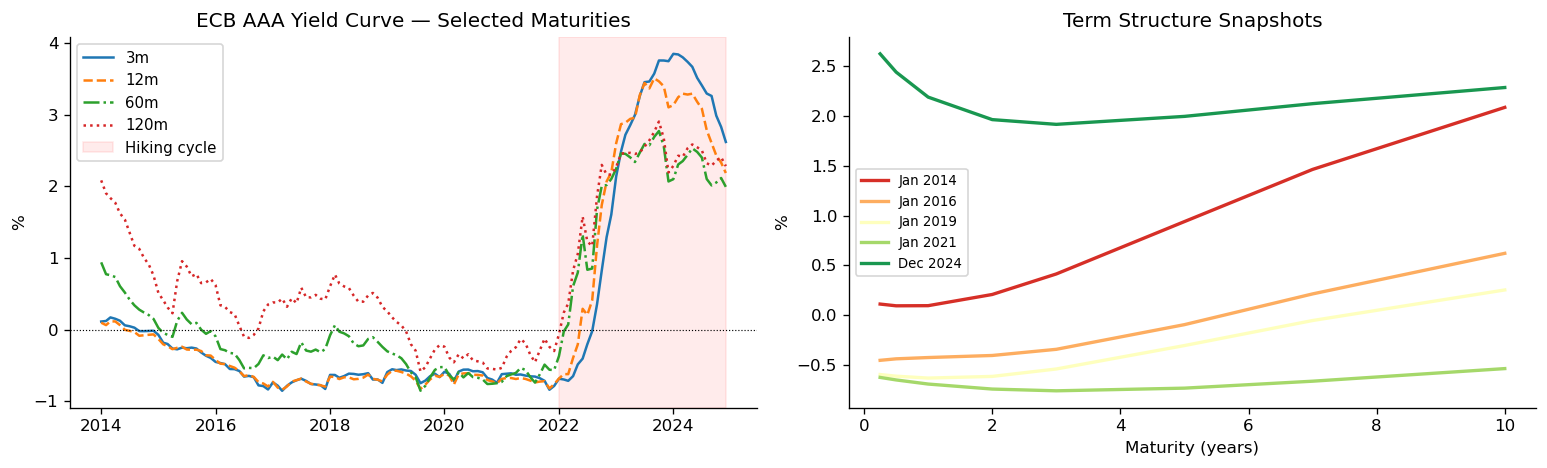

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
for col, ls in zip(["3m", "12m", "60m", "120m"], ["-", "--", "-.", ":"]):
    ax.plot(yields.index, yields[col], lw=1.5, ls=ls, label=col)
ax.axhline(0, color="black", lw=0.7, ls=":")
ax.axvspan(pd.Timestamp("2022-01-01"), yields.index[-1], alpha=0.08, color="red", label="Hiking cycle")
ax.set_title("ECB AAA Yield Curve — Selected Maturities")
ax.set_ylabel("%")
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

# Term structure snapshots
ax = axes[1]
snap_dates = [yields.index[0], yields.index[24], yields.index[60], yields.index[84], yields.index[-1]]
cmap = plt.cm.RdYlGn(np.linspace(0.1, 0.9, len(snap_dates)))
tau_yrs = MATURITIES / 12
for d, c in zip(snap_dates, cmap):
    ax.plot(tau_yrs, yields.loc[d], color=c, lw=2, label=d.strftime("%b %Y"))
ax.set_title("Term Structure Snapshots")
ax.set_xlabel("Maturity (years)")
ax.set_ylabel("%")
ax.legend(fontsize=8)

fig.tight_layout()
plt.show()

## 3. Preliminary OLS Nelson-Siegel Factor Extraction

Before running the full Bayesian DL model (notebook 03), we extract factors via OLS:
at each time $t$, regress $\mathbf{y}_t$ on the fixed loading matrix $\boldsymbol{\Lambda}$.

This is fast and sufficient to motivate the regime structure.

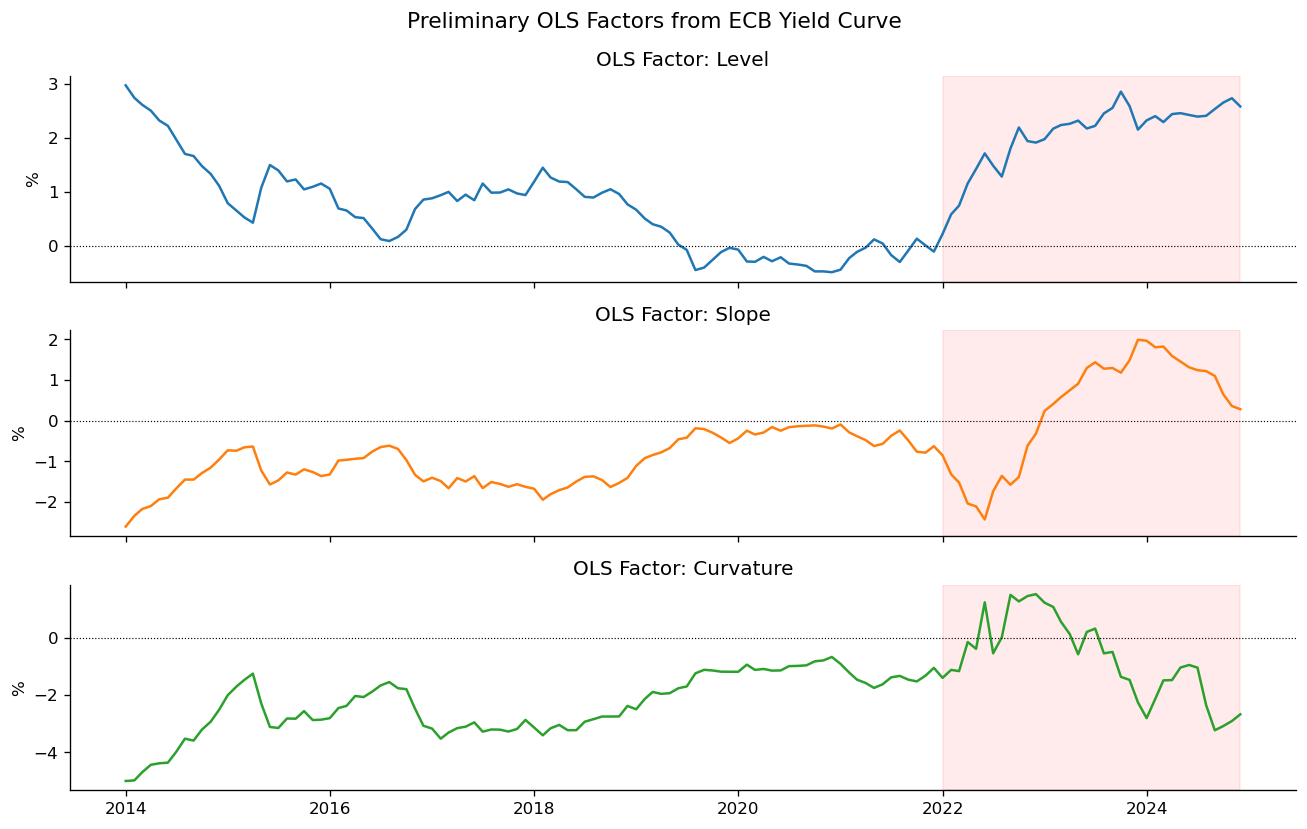

Level factor range: -0.49 to 2.98
Regime 0 (low rate): Level deeply negative 2015-2021
Regime 1 (hiking):   Level surges post-2022


In [4]:
Lambda = ns_loadings(MATURITIES)  # (J, 3)
y_obs  = yields.values             # (T, J)

# OLS: for each t, regress y_t on Lambda to get [L_t, S_t, C_t]
# Equivalently: F = (Lambda'Lambda)^{-1} Lambda' Y'
factors_ols = np.linalg.lstsq(Lambda, y_obs.T, rcond=None)[0].T  # (T, 3)

dates = yields.index
fig, axes = plt.subplots(3, 1, figsize=(11, 7), sharex=True)
names_c = [("Level", "#1f77b4"), ("Slope", "#ff7f0e"), ("Curvature", "#2ca02c")]
for i, (ax, (name, c)) in enumerate(zip(axes, names_c)):
    ax.plot(dates, factors_ols[:, i], color=c, lw=1.5)
    ax.axhline(0, color="black", lw=0.7, ls=":")
    ax.axvspan(pd.Timestamp("2022-01-01"), dates[-1], alpha=0.08, color="red")
    ax.set_ylabel("%")
    ax.set_title(f"OLS Factor: {name}")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
fig.suptitle("Preliminary OLS Factors from ECB Yield Curve", fontsize=13)
fig.tight_layout()
plt.show()

print("Level factor range:", round(factors_ols[:, 0].min(), 2), "to", round(factors_ols[:, 0].max(), 2))
print("Regime 0 (low rate): Level deeply negative 2015-2021")
print("Regime 1 (hiking):   Level surges post-2022")

## 4. Simulate Deposit Rates on Real Factors

We apply the ECM regime-switching DGP to the real OLS factors.
This gives us synthetic deposit rate data that:
- Has near-zero pass-through (2014–2021) reflecting the low-rate environment.
- Shows significant pass-through (2022–2024) during the hiking cycle.
- Exhibits sluggish adjustment via the ECM term.

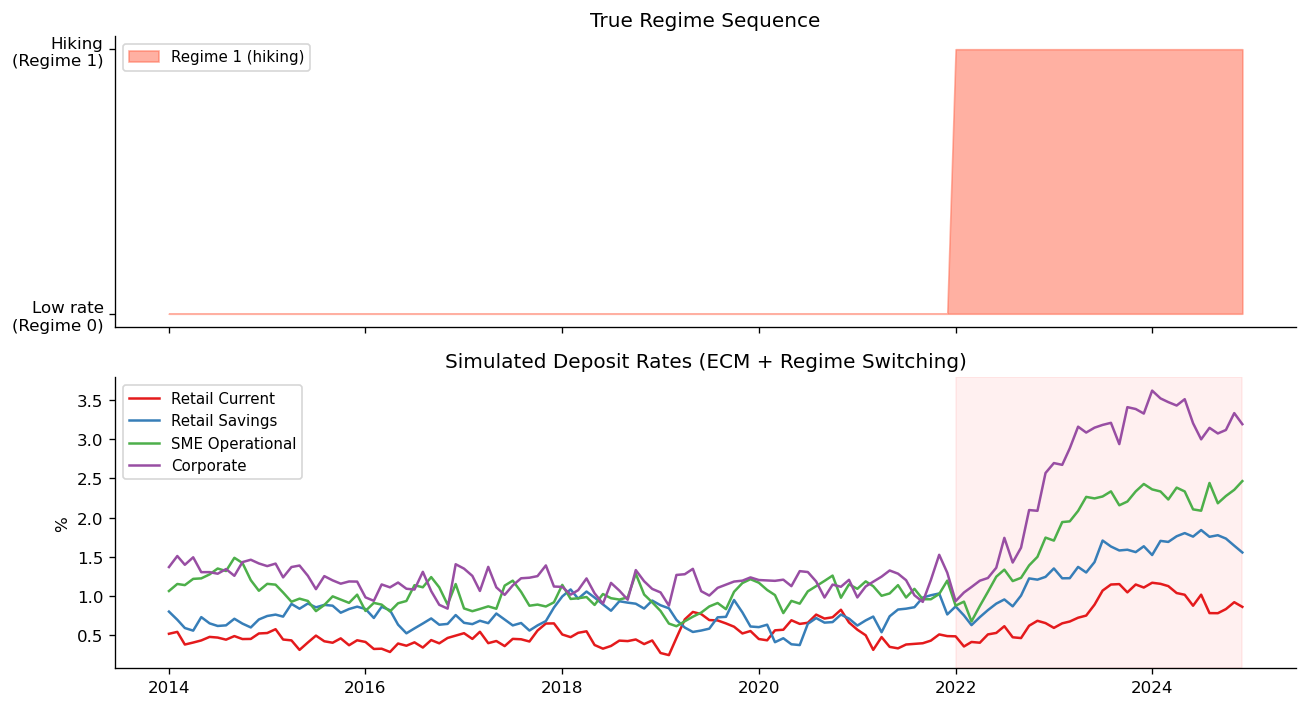

In [5]:
T = len(yields)
rng = np.random.default_rng(42)

deposit_rates, regime_seq = simulate_deposit_rates_ecm(factors_ols, rng, dates=dates)
deposits_df = pd.DataFrame(deposit_rates, index=dates, columns=SEGMENTS)

# Regime sequence and deposit rates
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)

ax = axes[0]
ax.fill_between(dates, regime_seq, color="tomato", alpha=0.5, label="Regime 1 (hiking)")
ax.set_yticks([0, 1])
ax.set_yticklabels(["Low rate\n(Regime 0)", "Hiking\n(Regime 1)"])
ax.set_title("True Regime Sequence")
ax.legend(loc="upper left", fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

ax = axes[1]
for seg, c in zip(SEGMENTS, SEG_COLORS):
    ax.plot(dates, deposits_df[seg], color=c, lw=1.5, label=seg)
ax.axvspan(pd.Timestamp("2022-01-01"), dates[-1], alpha=0.06, color="red")
ax.set_title("Simulated Deposit Rates (ECM + Regime Switching)")
ax.set_ylabel("%")
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

fig.tight_layout()
plt.show()

## 5. True DGP Parameters

For reference, the true parameters used to simulate deposit rates.

In [6]:
print("=" * 58)
print("TRUE ECM PARAMETERS")
print("=" * 58)
print(f"\n{'Regime 0 (low rate) — beta_L':}")
for s, seg in enumerate(SEGMENTS):
    print(f"  {seg:<22}: beta_L={TRUE_BETA_L_R0[s]:.3f}")
print(f"\n{'Regime 1 (hiking) — beta_L':}")
for s, seg in enumerate(SEGMENTS):
    print(f"  {seg:<22}: beta_L={TRUE_BETA_L_R1[s]:.3f}")
print(f"\n{'Adjustment speeds (gamma):':}")
for s, seg in enumerate(SEGMENTS):
    print(f"  {seg:<22}: gamma={TRUE_GAMMA[s]:.3f}")
    half_life = -np.log(2) / np.log(1 + TRUE_GAMMA[s])
    print(f"  {'':22}  half-life = {half_life:.1f} months")

TRUE ECM PARAMETERS

Regime 0 (low rate) — beta_L
  Retail Current        : beta_L=0.030
  Retail Savings        : beta_L=0.050
  SME Operational       : beta_L=0.080
  Corporate             : beta_L=0.150

Regime 1 (hiking) — beta_L
  Retail Current        : beta_L=0.200
  Retail Savings        : beta_L=0.350
  SME Operational       : beta_L=0.500
  Corporate             : beta_L=0.750

Adjustment speeds (gamma):
  Retail Current        : gamma=-0.200
                          half-life = 3.1 months
  Retail Savings        : gamma=-0.250
                          half-life = 2.4 months
  SME Operational       : gamma=-0.300
                          half-life = 1.9 months
  Corporate             : gamma=-0.400
                          half-life = 1.4 months


## 6. Save

Save ECB yields, OLS factors, simulated deposits, and regime sequence to `../data/ecb_data.pkl`.

Keys: `yields`, `factors_ols`, `deposits`, `regime_seq`.

In [7]:
os.makedirs("../data", exist_ok=True)
ecb_data = {
    "yields":      yields,
    "factors_ols": pd.DataFrame(factors_ols, index=dates, columns=["Level", "Slope", "Curvature"]),
    "deposits":    deposits_df,
    "regime_seq":  pd.Series(regime_seq, index=dates, name="regime"),
}
with open("../data/ecb_data.pkl", "wb") as f:
    pickle.dump(ecb_data, f)
print("Saved to ../data/ecb_data.pkl")
print(f"Keys: {list(ecb_data.keys())}")
print(f"yields shape: {ecb_data['yields'].shape}")
print(f"deposits shape: {ecb_data['deposits'].shape}")
print(f"regime_seq value counts:")
print(ecb_data['regime_seq'].value_counts().sort_index())

Saved to ../data/ecb_data.pkl
Keys: ['yields', 'factors_ols', 'deposits', 'regime_seq']
yields shape: (132, 8)
deposits shape: (132, 4)
regime_seq value counts:
regime
0    96
1    36
Name: count, dtype: int64
